# Curved-sky J3 loss: spectra and loss terms of given Q/U maps

All operations are in `src/loss_tools.py`, as plain numpy functions on maps in μK:

| function | what it does |
|---|---|
| `setup()` | geometry, spectra, beam, transforms → `ctx` |
| `load_valid_map(ctx, j)` | observed Q, U, mask, σ² of validation map j |
| `true_signal(ctx, j)` | true CMB Q, U of map j (no beam; `beam=True` for the beamed one) |
| `qu_to_eb`, `eb_to_qu` | A (Q,U → E,B a_ℓm) and Y (E,B → Q,U) |
| `apply_beam`, `bandlimit` | Y B_ℓ A and Y A |
| `spectrum(ctx, Q, U, mask)` | pseudo-C_ℓ EE, BB |
| `term_data`, `chi2_map` | likelihood term and its per-pixel map |
| `term_prior`, `prior_per_ell` | prior term and its contribution per ℓ |
| `loss_terms` | both terms and J3 |
| `print_times(ctx)` | time spent in each operation since the last call |

Data: the validation set copied from the cluster (`results/task2/cluster/`).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
import loss_tools as lt

ctx = lt.setup(nthread=8)

## Maps

In [2]:
j = 0
Qobs, Uobs, mask, sigma2 = lt.load_valid_map(ctx, j)     # observed: mask * (beamed signal + noise)
Qs, Us = lt.true_signal(ctx, j)                           # true signal, no beam (the Wiener-filter target)
Qsb, Usb = lt.true_signal(ctx, j, beam=True)              # true signal with beam
Qs1124, Us1124 = lt.true_signal(ctx, j, lmax_signal=1124)  # same realization, generated only up to l = 1124
print(Qobs.shape, 'observed pixels:', int(mask.sum()))

(320, 1120) observed pixels: 286159


## Spectrum of any Q, U

`spectrum` = `qu_to_eb` (pixell `curvedsky.map2alm(..., spin=2, method='2d')`, as in notebook 02) of the masked maps, then `alm2cl` / w₂. This is a pseudo-C_ℓ: the binary SO mask mixes E into B, which dominates BB at low ℓ (Task 1). Signal power above ℓ = 1124, beyond the grid's exact band limit, aliases into the highest ℓ.

N = 5.000e-07 muK^2 sr


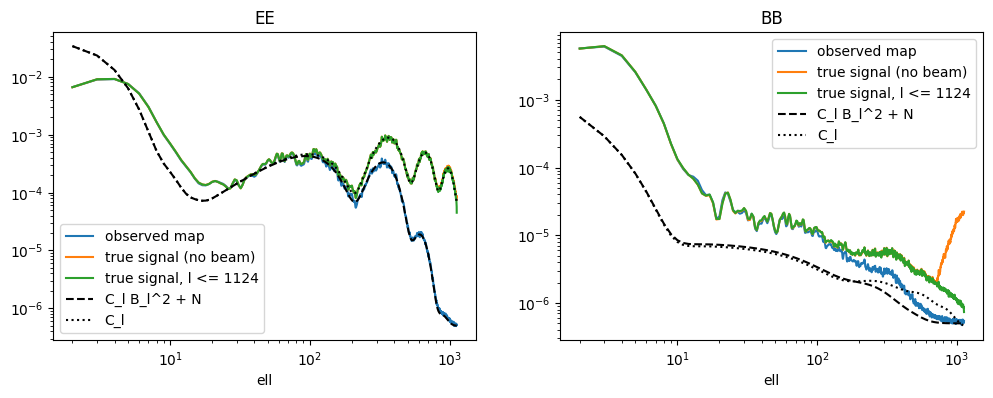

A: Q,U -> E,B         :    3 calls,   0.842 s total, 0.2807 s per call
alm2cl                :    3 calls,   0.017 s total, 0.0056 s per call


In [3]:
ell, cl_obs = lt.spectrum(ctx, Qobs, Uobs, mask)
ell, cl_sig = lt.spectrum(ctx, Qs, Us, mask)
ell, cl_sig1124 = lt.spectrum(ctx, Qs1124, Us1124, mask)
area = ctx.mask.pixsizemap()                                            # pixel solid angle [sr]
N = np.sum(mask * sigma2 * area * area) / np.sum(mask * area)           # mean white-noise level N = <sigma^2 x area> [muK^2 sr]
print(f'N = {N:.3e} muK^2 sr')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for k, (name, C) in enumerate((('EE', ctx.clee), ('BB', ctx.clbb))):
    l = ell[2:]
    ax[k].loglog(l, cl_obs[k, 2:], label='observed map')
    ax[k].loglog(l, cl_sig[k, 2:], label='true signal (no beam)')
    ax[k].loglog(l, cl_sig1124[k, 2:], label='true signal, l <= 1124')
    ax[k].loglog(l, C[l] * ctx.bl[l]**2 + N, 'k--', label='C_l B_l^2 + N')
    ax[k].loglog(l, C[l], 'k:', label='C_l')
    ax[k].set_title(name); ax[k].set_xlabel('ell'); ax[k].legend()
plt.show()
lt.print_times(ctx)

In [7]:
ell

array([   0,    1,    2, ..., 1122, 1123, 1124], shape=(1125,))

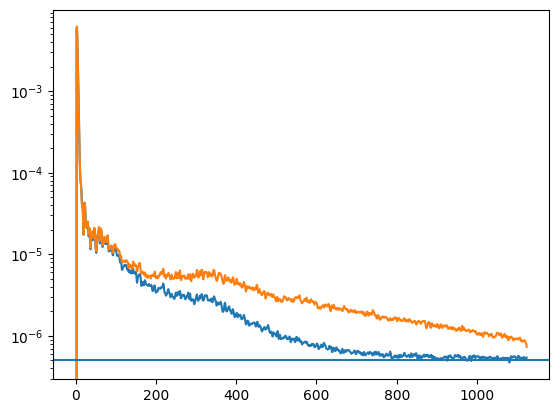

In [9]:
plt.plot(ell, cl_obs[1,:], label='clobs')
plt.plot(ell, cl_sig1124[1,:], label='clsig')
plt.axhline(N)
plt.yscale('log')

## Loss terms for a prediction

Choose any prediction `Qp, Up` (μK, no beam) and compare it with the expected values for a perfect prediction. The training loader subtracts the mean of the observed maps, so do the same here.

In [4]:
Qd, Ud = lt.subtract_mean(Qobs, Uobs)       # data as seen by the loss
mean_Q, mean_U = Qobs.mean(), Uobs.mean()

predictions = {
    'true signal':              (Qs - mean_Q, Us - mean_U),
    'Y A (true signal)':        lt.bandlimit(ctx, Qs - mean_Q, Us - mean_U),
    'true signal, l <= 1124':   (Qs1124 - mean_Q, Us1124 - mean_U),
    'half of the true signal':  (0.5 * (Qs - mean_Q), 0.5 * (Us - mean_U)),
    'zero':                     (0 * Qs - mean_Q, 0 * Us - mean_U),
}
print('expected for a perfect prediction:', {k: round(v, 4) for k, v in lt.expected_values(ctx, mask).items()})
for name, (Qp, Up) in predictions.items():
    t = lt.loss_terms(ctx, Qd, Ud, Qp, Up, mask, sigma2)
    print(f'{name:26s}: ' + ', '.join(f'{k} = {v:.4f}' for k, v in t.items()))
lt.print_times(ctx)

expected for a perfect prediction: {'data': 1.5969, 'prior_E': np.float64(0.4995), 'prior_B': np.float64(0.4995)}


true signal               : data = 1.6070, prior_E = 0.5205, prior_B = 6.7993, prior = 7.3198, J3 = 8.9268


Y A (true signal)         : data = 1.6070, prior_E = 0.5179, prior_B = 6.6583, prior = 7.1762, J3 = 8.7831


true signal, l <= 1124    : data = 1.5946, prior_E = 0.5008, prior_B = 0.9570, prior = 1.4578, J3 = 3.0524


half of the true signal   : data = 11.0311, prior_E = 0.1301, prior_B = 1.6998, prior = 1.8300, J3 = 12.8610


zero                      : data = 39.5118, prior_E = 0.0000, prior_B = 0.0003, prior = 0.0003, J3 = 39.5121
A: Q,U -> E,B         :   11 calls,   2.273 s total, 0.2066 s per call
Y: E,B -> Q,U         :    6 calls,   1.185 s total, 0.1975 s per call
data term (pixels)    :    5 calls,   0.054 s total, 0.0109 s per call
prior term (alm)      :    5 calls,   0.010 s total, 0.0019 s per call


## Where each term is large

`pred` is any of the predictions above. The prior per ℓ is divided by its expected value f_sky (2ℓ+1).

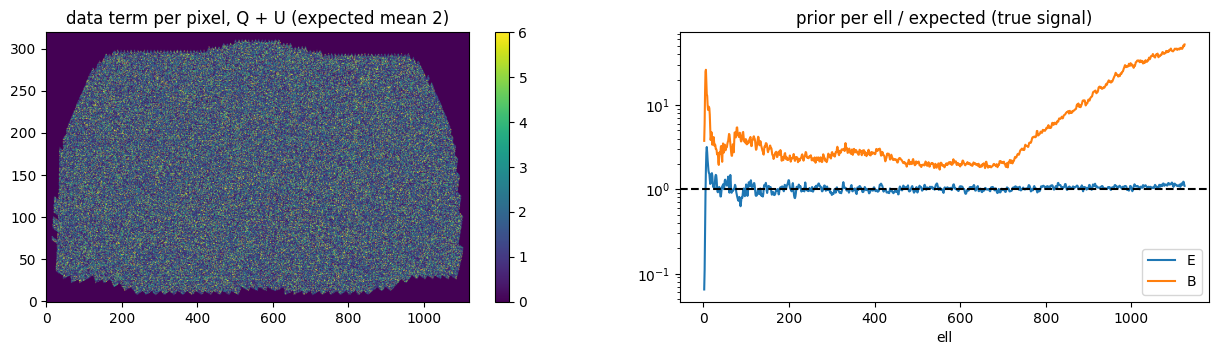

In [5]:
pred = 'true signal'
Qp, Up = predictions[pred]
chi2 = lt.chi2_map(ctx, Qd, Ud, Qp, Up, mask, sigma2)          # per-pixel data term, Q and U
pl = lt.prior_per_ell(ctx, Qp, Up)                             # prior contribution per ell, E and B

fig, ax = plt.subplots(1, 2, figsize=(15, 3.5))
im = ax[0].imshow(chi2.sum(0), origin='lower', vmax=6, aspect='auto'); plt.colorbar(im, ax=ax[0])
ax[0].set_title('data term per pixel, Q + U (expected mean 2)')
expected = ctx.mask.pixsizemap().sum() / (4 * np.pi) * (2 * ell + 1)
ax[1].semilogy(ell[2:], pl[0, 2:] / expected[2:], label='E')
ax[1].semilogy(ell[2:], pl[1, 2:] / expected[2:], label='B')
ax[1].axhline(1, color='k', ls='--'); ax[1].set_xlabel('ell'); ax[1].set_title(f'prior per ell / expected ({pred})'); ax[1].legend()
plt.show()

## Time of the operations of one training step

One step of training calls A and Y once each in the forward pass, and their adjoints once each in the backward pass, which take about as long. The timings below are for this machine, `nthread` threads and `ctx.method` (training uses `'cyl'`, about 2× faster than `'2d'`).

In [6]:
for _ in range(3):
    lt.loss_terms(ctx, Qd, Ud, Qp, Up, mask, sigma2)
lt.print_times(ctx)

A: Q,U -> E,B         :    8 calls,   1.777 s total, 0.2222 s per call
Y: E,B -> Q,U         :    4 calls,   0.795 s total, 0.1989 s per call
data term (pixels)    :    4 calls,   0.055 s total, 0.0136 s per call
prior term (alm)      :    4 calls,   0.015 s total, 0.0037 s per call
